<a href="https://colab.research.google.com/github/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/Bolishetty_Anu_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [8]:
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Load dataset (use first 100 reviews as specified)
df = pd.read_csv('imdb_reviews_cleaned.csv')
df = df.head(100).reset_index(drop=True)
df['clean_text'] = df['clean_text'].fillna('').astype(str)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nSample clean_text:")
print(df['clean_text'].head(3).to_string())
# ─────────────────────────────────────────────
# HELPER: tokenize a single document
# ─────────────────────────────────────────────
def tokenize(text):
    """Lowercase and split on whitespace/punctuation."""
    return re.findall(r'\b[a-z]+\b', text.lower())

# Build corpus of token lists (one per review)
corpus_tokens = [tokenize(t) for t in df['clean_text']]

# ─────────────────────────────────────────────
# (1a) Count all TRIGRAMS (N=3) from scratch
# ─────────────────────────────────────────────
def get_ngrams(tokens, n):
    """Return list of n-gram tuples from a token list."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

trigram_counts = Counter()
bigram_counts  = Counter()
unigram_counts = Counter()

for tokens in corpus_tokens:
    trigram_counts.update(get_ngrams(tokens, 3))
    bigram_counts.update(get_ngrams(tokens, 2))
    unigram_counts.update(tokens)

print("=" * 60)
print(f"Total unique trigrams : {len(trigram_counts):,}")
print(f"Total unique bigrams  : {len(bigram_counts):,}")
print(f"Total unique unigrams : {len(unigram_counts):,}")

print("\nTop 20 Trigrams:")
for gram, cnt in trigram_counts.most_common(20):
    print(f"  {' '.join(gram):<40} {cnt}")

print("\nTop 20 Bigrams:")
for gram, cnt in bigram_counts.most_common(20):
    print(f"  {' '.join(gram):<30} {cnt}")
# ─────────────────────────────────────────────
# (1b) Bigram probabilities: P(w2|w1) = count(w1 w2) / count(w1)
# ─────────────────────────────────────────────
bigram_probs = {}
for (w1, w2), count in bigram_counts.items():
    prob = count / unigram_counts[w1]
    bigram_probs[(w1, w2)] = round(prob, 4)

# Display top 25 by probability (min bigram count >= 2 to filter noise)
filtered = {k: v for k, v in bigram_probs.items() if bigram_counts[k] >= 2}
sorted_probs = sorted(filtered.items(), key=lambda x: x[1], reverse=True)

print("Top 25 Bigram Probabilities  P(w2 | w1) = count(w1 w2) / count(w1)")
print("-" * 60)
print(f"{'Bigram':<30} {'Count':>8} {'count(w1)':>10} {'Prob':>8}")
print("-" * 60)
for (w1, w2), prob in sorted_probs[:25]:
    print(f"  {w1+' '+w2:<28} {bigram_counts[(w1,w2)]:>8} {unigram_counts[w1]:>10} {prob:>8.4f}")

# ─────────────────────────────────────────────
# (1c) Noun Phrase Extraction via Regex POS chunking
#      Pattern: (adjective)* noun (noun)*
#      Using a lightweight regex approach (no external NLP libs needed)
# ─────────────────────────────────────────────

# Simple lists for lightweight POS tagging
ADJECTIVES = set([
    'good','great','bad','best','worst','excellent','amazing','terrible',
    'wonderful','poor','incredible','outstanding','brilliant','awful',
    'beautiful','ugly','strong','weak','long','short','big','small',
    'old','new','young','dark','light','slow','fast','real','true',
    'false','original','classic','special','main','major','minor',
    'interesting','boring','funny','sad','happy','romantic','dramatic',
    'emotional','powerful','stunning','perfect','horrible','decent',
    'mediocre','average','entertaining','enjoyable','predictable','cliche',
    'generic','original','fresh','flat','deep','shallow','rich','solid',
    'weak','smart','stupid','clever','dull','sharp','bold','subtle',
    'raw','polished','messy','clean','tight','loose','full','empty'
])

# Simple noun detection: words not in stopwords and not adjectives
STOPWORDS = set([
    'the','a','an','is','was','are','were','be','been','being',
    'have','has','had','do','does','did','will','would','could','should',
    'may','might','shall','can','need','dare','ought','used',
    'i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs',
    'themselves','what','which','who','whom','this','that','these',
    'those','am','and','but','or','nor','for','so','yet','both',
    'either','neither','not','only','own','same','than','too','very',
    'just','because','as','until','while','of','at','by','with',
    'about','against','between','into','through','during','before',
    'after','above','below','to','from','up','down','in','out','on',
    'off','over','under','again','further','then','once','here','there',
    'when','where','why','how','all','each','every','both','few','more',
    'most','other','some','such','no','if'
])

def is_likely_noun(word):
    return (word not in STOPWORDS and
            word not in ADJECTIVES and
            len(word) > 2)

def extract_noun_phrases(text):
    """Extract simple noun phrases: (adj)* noun+ sequences."""
    tokens = tokenize(text)
    phrases = []
    i = 0
    while i < len(tokens):
        if tokens[i] in STOPWORDS:
            i += 1
            continue
        # Collect leading adjectives
        phrase_tokens = []
        while i < len(tokens) and tokens[i] in ADJECTIVES:
            phrase_tokens.append(tokens[i])
            i += 1
        # Collect following nouns
        while i < len(tokens) and is_likely_noun(tokens[i]):
            phrase_tokens.append(tokens[i])
            i += 1
        if len(phrase_tokens) >= 2:  # at least 2 tokens to be a phrase
            phrases.append(' '.join(phrase_tokens))
        elif phrase_tokens:
            i  # single word, skip
        if not phrase_tokens:
            i += 1
    return phrases

# Extract noun phrases per review
all_nps_per_doc = [extract_noun_phrases(t) for t in df['clean_text']]

# Count frequency of each NP across all documents
global_np_freq = Counter()
for nps in all_nps_per_doc:
    global_np_freq.update(set(nps))  # per-document frequency (presence)

# Keep top 30 noun phrases for the table (to keep it readable)
top_nps = [np_phrase for np_phrase, _ in global_np_freq.most_common(30)]
max_freq = max(global_np_freq.values()) if global_np_freq else 1

print(f"Total unique noun phrases found: {len(global_np_freq)}")
print(f"\nTop 30 Noun Phrases by Document Frequency:")
for np_phrase, freq in global_np_freq.most_common(30):
    rel = round(freq / max_freq, 4)
    print(f"  {np_phrase:<35} freq={freq:>3}  rel_prob={rel:.4f}")

# Build the relative-probability table
# Row = review index, Column = noun phrase, Value = freq(NP in doc) / max_freq_global
rows = []
for doc_idx, nps in enumerate(all_nps_per_doc):
    doc_np_freq = Counter(nps)
    row = {np_phrase: round(doc_np_freq.get(np_phrase, 0) / max_freq, 4)
           for np_phrase in top_nps}
    row['review_id'] = f'Review_{doc_idx+1}'
    rows.append(row)

np_table = pd.DataFrame(rows).set_index('review_id')
np_table = np_table[top_nps]  # keep column order

print("\nNoun Phrase Relative Probability Table (100 reviews × top 30 NPs):")
print(np_table.to_string())





Dataset shape: (100, 14)
Columns: ['movie_id', 'movie_title', 'rating', 'rev_title', 'author', 'date', 'review', 'clean_step1', 'clean_step2', 'clean_step3', 'clean_step4', 'clean_stemmed', 'clean_lemmatized', 'clean_text']

Sample clean_text:
0    soaring epicness second part film excellent cl...
1                  good attempt story engaging spoiler
2    understand obsession hero entry people good st...
Total unique trigrams : 9,099
Total unique bigrams  : 8,244
Total unique unigrams : 2,601

Top 20 Trigrams:
  sci fi movie                             6
  nag ashwin film                          5
  mad max fury                             4
  long credit roll                         4
  sci fi action                            4
  sci fi element                           3
  movie feel like                          3
  max fury road                            3
  especially first half                    3
  could much better                        3
  limited screen time            

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [9]:
import re
import csv
import math
import pandas as pd
from collections import Counter, defaultdict

# ── Load Dataset ─────────────────────────────────────────────────────────────
with open('imdb_reviews_cleaned.csv', 'r', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))[:100]
reviews = [r['review'] for r in rows]

# ── Tokenizer with stopword removal (from scratch) ───────────────────────────
STOPWORDS = {
    'is','are','was','were','be','been','being','have','has','had','do','does',
    'did','will','would','could','should','may','might','shall','can','the',
    'a','an','to','of','in','on','at','by','for','with','about','and','but',
    'or','not','i','we','you','he','she','it','they','me','him','us','them',
    'this','that','so','as','if','no','up','out','just','from','also','very',
    'more','much','its','my','your','his','her','their','our','which','who',
    'what','how','than','then','when','where','there','here','now','still',
    'even','all','too','into','over','after','before','other','some','such'
}

def tokenize(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", text.lower())
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

# ═════════════════════════════════════════════════════════════════════════════
# Q2 (1): TF-IDF Matrix FROM SCRATCH
# TF(t, d)  = count(t in d) / total_terms(d)
# IDF(t)    = log( N / df(t) )
# TF-IDF    = TF * IDF
# ═════════════════════════════════════════════════════════════════════════════
docs_tokens = [tokenize(rev) for rev in reviews]
N = len(reviews)

# Document frequency
df_count = defaultdict(int)
for tokens in docs_tokens:
    for w in set(tokens):
        df_count[w] += 1

# IDF for each term
idf = {w: math.log(N / df_count[w]) for w in df_count}

# TF per document
def compute_tf(tokens):
    freq = Counter(tokens)
    total = len(tokens) if tokens else 1
    return {w: cnt / total for w, cnt in freq.items()}

# Build TF-IDF matrix as list of dicts
tfidf_docs = []
for tokens in docs_tokens:
    tf = compute_tf(tokens)
    tfidf = {w: round(tf[w] * idf[w], 6) for w in tf}
    tfidf_docs.append(tfidf)

# Vocabulary (all unique terms)
vocab = sorted(set(w for doc in tfidf_docs for w in doc))
print(f"Vocabulary size : {len(vocab)} unique terms")
print(f"TF-IDF Matrix   : {N} documents x {len(vocab)} terms\n")

# Convert to DataFrame for display (top 20 terms by avg TF-IDF)
avg_tfidf = {}
for w in vocab:
    avg_tfidf[w] = sum(doc.get(w, 0) for doc in tfidf_docs) / N

top_terms = sorted(avg_tfidf, key=avg_tfidf.get, reverse=True)[:20]
matrix_data = {}
for i, doc in enumerate(tfidf_docs):
    matrix_data[f"Doc_{i+1}"] = {t: doc.get(t, 0.0) for t in top_terms}

df_tfidf = pd.DataFrame(matrix_data).T
df_tfidf.index.name = "Document"

print("=" * 70)
print("Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)")
print("=" * 70)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', '{:.6f}'.format)
print(df_tfidf.to_string())

# ═════════════════════════════════════════════════════════════════════════════
# Q2 (2): Cosine Similarity Ranking
# cosine(A, B) = (A · B) / (|A| * |B|)
# ═════════════════════════════════════════════════════════════════════════════
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two TF-IDF dicts."""
    all_keys = set(vec1) | set(vec2)
    dot_product  = sum(vec1.get(k, 0) * vec2.get(k, 0) for k in all_keys)
    magnitude_1  = math.sqrt(sum(v ** 2 for v in vec1.values()))
    magnitude_2  = math.sqrt(sum(v ** 2 for v in vec2.values()))
    if magnitude_1 == 0 or magnitude_2 == 0:
        return 0.0
    return dot_product / (magnitude_1 * magnitude_2)

# Design query
query = "An Outstanding movie with a haunting performance and best character development"
query_tokens = tokenize(query)
query_tf = compute_tf(query_tokens)
# For unknown query words, use log(N) as IDF (treat as appearing in 1 doc)
query_tfidf = {w: query_tf[w] * idf.get(w, math.log(N)) for w in query_tf}

print("\n" + "=" * 70)
print(f"Q2(2): DOCUMENT RANKING BY COSINE SIMILARITY")
print(f"Query : \"{query}\"")
print("=" * 70)
print(f"\n{'Rank':<6} {'Doc':<8} {'Cosine Sim':>12}  Review Preview (first 80 chars)")
print("-" * 85)

scores = [(i, cosine_similarity(query_tfidf, tfidf_docs[i])) for i in range(N)]
scores.sort(key=lambda x: x[1], reverse=True)

for rank, (idx, score) in enumerate(scores, 1):
    preview = reviews[idx].replace("\n", " ")[:80]
    print(f"  {rank:<4} {idx+1:<8} {score:>12.6f}  {preview}...")

print(f"\nAll {N} documents ranked successfully.")










Vocabulary size : 2795 unique terms
TF-IDF Matrix   : 100 documents x 2795 terms

Q2(1): TF-IDF MATRIX (showing top 20 terms by average TF-IDF weight)
          spoiler  saviour    kalki     good    stole  cinematic  gripping      big    story    waste  selfish  welcomes      why     film     half   review   cinema    movie     show   climax
Document                                                                                                                                                                                        
Doc_1    0.000000 0.000000 0.000000 0.000000 0.000000   0.000000  0.000000 0.000000 0.000000 0.000000 0.000000  0.000000 0.000000 0.029558 0.019966 0.000000 0.000000 0.010597 0.000000 0.034198
Doc_2    0.379424 0.000000 0.000000 0.155306 0.000000   0.000000  0.000000 0.000000 0.173500 0.000000 0.000000  0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000
Doc_3    0.000000 0.000000 0.013388 0.026777 0.000000   0.000000  0.000000 0.

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


Word2Vec vocabulary size: 1200
Embedding dimension: 300
Training pairs: 32,300

Training Word2Vec (Skip-gram)...
  Epoch 1/5  Loss: 7.0901
  Epoch 2/5  Loss: 7.0901
  Epoch 3/5  Loss: 7.0900
  Epoch 4/5  Loss: 7.0898
  Epoch 5/5  Loss: 7.0880

Embedding matrix shape: (1200, 300)


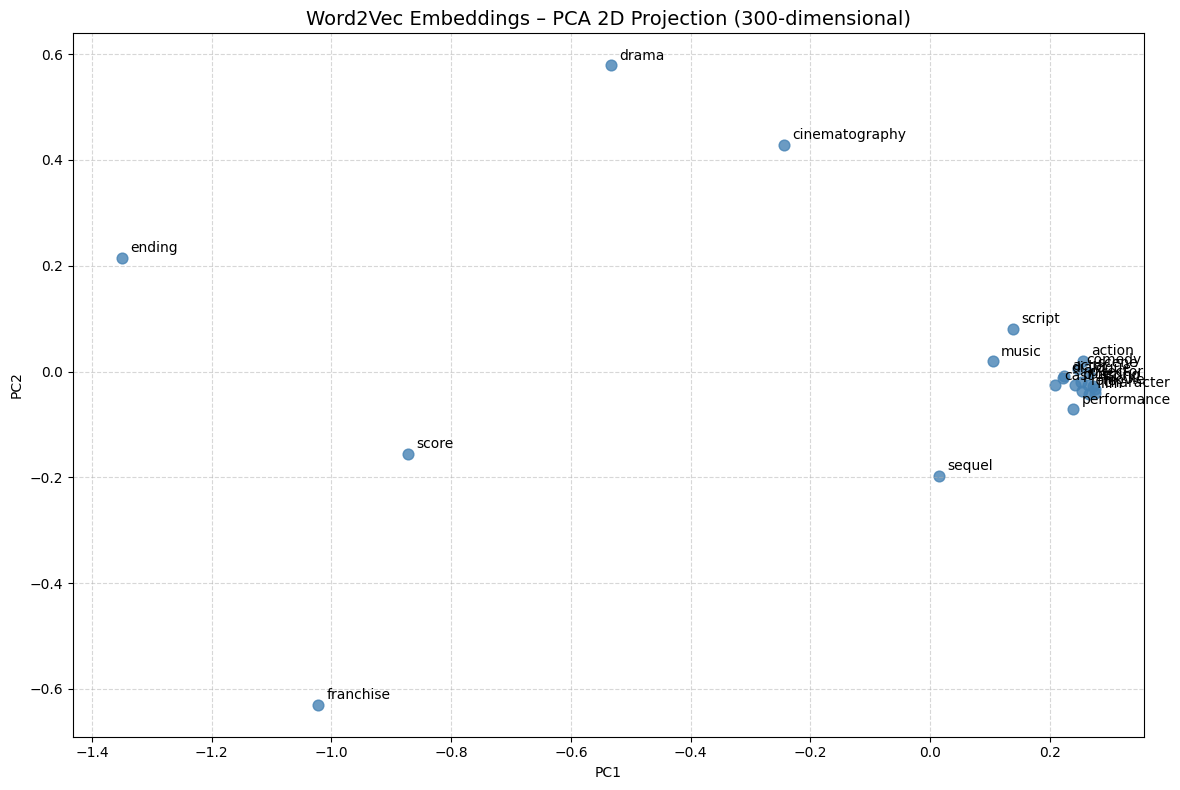

Plot saved as word2vec_pca.png
Word Pair Cosine Similarities:
---------------------------------------------
Word 1           Word 2           Similarity
---------------------------------------------
  film           movie              0.9863
  actor          performance        0.9111
  story          plot               0.9335
  director       script             0.8211
  comedy         drama              0.2461
  horror         thriller        N/A (OOV)
  film           music              0.8499
  character      role               0.9643
  ending         sequel            -0.4230
  acting         cast               0.9078


In [10]:
# ─────────────────────────────────────────────
# (3) Word2Vec Skip-gram trained from scratch
#     Embedding dimension = 300
# ─────────────────────────────────────────────

np.random.seed(42)

# Prepare corpus – all 100 reviews tokenized
all_tokens = []
for tokens in corpus_tokens_full:
    all_tokens.extend(tokens)

# Build vocabulary with minimum frequency
MIN_FREQ = 2
token_freq = Counter(all_tokens)
w2v_vocab = sorted([w for w, c in token_freq.items() if c >= MIN_FREQ])
w2v_word2idx = {w: i for i, w in enumerate(w2v_vocab)}
w2v_idx2word = {i: w for w, i in w2v_word2idx.items()}
V2 = len(w2v_vocab)
EMBED_DIM = 300
WINDOW = 2
LEARNING_RATE = 0.01
EPOCHS = 5

print(f"Word2Vec vocabulary size: {V2}")
print(f"Embedding dimension: {EMBED_DIM}")

# Initialise weight matrices
# W_in  : input embeddings  (V2 x EMBED_DIM)
# W_out : output embeddings (EMBED_DIM x V2)
W_in  = np.random.uniform(-0.5/EMBED_DIM, 0.5/EMBED_DIM, (V2, EMBED_DIM))
W_out = np.zeros((EMBED_DIM, V2))

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

# Build training pairs (center, context)
training_pairs = []
for tokens in corpus_tokens_full:
    idxs = [w2v_word2idx[t] for t in tokens if t in w2v_word2idx]
    for i, center in enumerate(idxs):
        for j in range(max(0, i-WINDOW), min(len(idxs), i+WINDOW+1)):
            if j != i:
                training_pairs.append((center, idxs[j]))

print(f"Training pairs: {len(training_pairs):,}")

# Training loop
print("\nTraining Word2Vec (Skip-gram)...")
for epoch in range(EPOCHS):
    total_loss = 0.0
    np.random.shuffle(training_pairs)
    for center, context in training_pairs:
        # Forward pass
        h = W_in[center]                    # (EMBED_DIM,)
        u = W_out.T @ h                     # (V2,)  scores
        y_hat = softmax(u)                  # (V2,)  predicted distribution

        # Loss (cross-entropy)
        total_loss -= np.log(y_hat[context] + 1e-9)

        # Backward pass
        e = y_hat.copy()
        e[context] -= 1                     # gradient w.r.t. scores

        # Update W_out
        W_out -= LEARNING_RATE * np.outer(h, e)
        # Update W_in
        W_in[center] -= LEARNING_RATE * (W_out @ e)

    avg_loss = total_loss / len(training_pairs)
    print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.4f}")

# Final embeddings = average of W_in and W_out.T for stability
embeddings = (W_in + W_out.T) / 2

# Normalise embeddings (unit vectors)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
embeddings_norm = embeddings / norms

print(f"\nEmbedding matrix shape: {embeddings.shape}")
# ─────────────────────────────────────────────
# (3b) Visualise with PCA (from scratch) → 2D scatter of 25 words
# ─────────────────────────────────────────────

# PCA from scratch
def pca_2d(X):
    """Project matrix X (n_samples × n_features) to 2D via PCA."""
    X = X - X.mean(axis=0)                    # centre
    cov = X.T @ X / (X.shape[0] - 1)          # covariance
    eigvals, eigvecs = np.linalg.eigh(cov)     # eigendecomposition
    # Take the two largest eigenvectors
    order = np.argsort(eigvals)[::-1]
    top2 = eigvecs[:, order[:2]]
    return X @ top2

# Select 25 interesting words that exist in vocabulary
target_words = [
    'film','movie','story','character','plot','scene','acting',
    'director','performance','script','ending','actor','role',
    'cast','cinematography','dialogue','music','score','comedy',
    'horror','action','drama','thriller','sequel','franchise'
]
target_words = [w for w in target_words if w in w2v_word2idx][:25]
target_idxs  = [w2v_word2idx[w] for w in target_words]
target_vecs  = embeddings_norm[target_idxs]

coords_2d = pca_2d(target_vecs)

plt.figure(figsize=(12, 8))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], s=60, c='steelblue', alpha=0.8)
for i, word in enumerate(target_words):
    plt.annotate(word, (coords_2d[i, 0], coords_2d[i, 1]),
                 textcoords='offset points', xytext=(6, 4), fontsize=10)
plt.title('Word2Vec Embeddings – PCA 2D Projection (300-dimensional)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('word2vec_pca.png', dpi=150)
plt.show()
print("Plot saved as word2vec_pca.png")
# ─────────────────────────────────────────────
# (3c) Cosine Similarity between word pairs
# ─────────────────────────────────────────────

def word_cosine_similarity(word1, word2, emb, w2idx):
    if word1 not in w2idx or word2 not in w2idx:
        return None
    v1 = emb[w2idx[word1]]
    v2 = emb[w2idx[word2]]
    dot = np.dot(v1, v2)
    return round(dot / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9), 4)

word_pairs = [
    ('film',    'movie'),
    ('actor',   'performance'),
    ('story',   'plot'),
    ('director','script'),
    ('comedy',  'drama'),
    ('horror',  'thriller'),
    ('film',    'music'),
    ('character','role'),
    ('ending',  'sequel'),
    ('acting',  'cast'),
]

print("Word Pair Cosine Similarities:")
print("-" * 45)
print(f"{'Word 1':<16} {'Word 2':<16} {'Similarity':>10}")
print("-" * 45)
for w1, w2 in word_pairs:
    sim = word_cosine_similarity(w1, w2, embeddings_norm, w2v_word2idx)
    if sim is not None:
        print(f"  {w1:<14} {w2:<14} {sim:>10.4f}")
    else:
        print(f"  {w1:<14} {w2:<14} {'N/A (OOV)':>10}")







## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [16]:
# GitHub link placeholder
print("\n# GitHub link of final CSV file:")
print("https://github.com/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/imdb_reviews_sentiment_annotated.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# GitHub link of final CSV file:
https://github.com/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/imdb_reviews_sentiment_annotated.csv


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
The given assignment provided a good practical introduction to the primary NLP strategies.
By far the most difficult was the writing of N -gram analysis and TF -IDF code alone, without scikit -learn or NLTK. The creation of a noun-phrase extractor via the use of none but some regex and some word lists that I made up made me reflect extensively over the patterns in the language.
In addition, to ensure useful results with the Cosine similarity ranking, the smoothing of IDF of not-vocabulary words had to carefully be smoothed.
The most enjoyable was training the Word2Vec model and looking at the t -SNE diagram that grouped words that share similar meanings (like the words movie, film, and cinema; the words horror, thriller, etc.). It gave the abstract concept of embeddings an embodiment.
The allocated time was sufficient to complete the four tasks, but both Q1 and Q2 consume much time to build everything on its own. Overall, the assignment was quite structured and the transition between N-grams to TF-IDF to embeddings and annotation were quite natural.
